In [6]:
from pathlib import Path

ROOT = Path(".")
DATA_DIR = ROOT / "data" / "raw"
OUT_DIR = ROOT / "output" / "climate"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MT_BOUNDARY_PATH = DATA_DIR / "municipios_mt.geojson"

In [7]:
from pathlib import Path
import json
import math
import pandas as pd
import geopandas as gpd
import ee

# caminhos
ROOT = Path(".")
DATA_DIR = ROOT / "data" / "raw"
OUT_DIR = ROOT / "output" / "climate"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# projeto do Google Cloud / Earth Engine
GCP_PROJECT = "310735038865"

# horizonte do MVP
HORIZON_7D_HOURS = 168
HORIZON_14D_HOURS = 336

# escala nativa aproximada do GFS no Earth Engine
GFS_SCALE_METERS = 27830

# bandas que vamos usar no MVP
GFS_BANDS = [
    "temperature_2m_above_ground",
    "relative_humidity_2m_above_ground",
    "u_component_of_wind_10m_above_ground",
    "v_component_of_wind_10m_above_ground",
    "total_precipitation_surface",
]

ModuleNotFoundError: No module named 'geopandas'

In [ ]:
ee.Authenticate()
ee.Initialize(project=GCP_PROJECT)

print("Earth Engine inicializado com sucesso.")

Earth Engine inicializado com sucesso.


In [ ]:
assert MT_BOUNDARY_PATH.exists(), f"Arquivo não encontrado: {MT_BOUNDARY_PATH}"

mt_gdf = gpd.read_file(MT_BOUNDARY_PATH)

# garante CRS geográfico
if mt_gdf.crs is None:
    mt_gdf = mt_gdf.set_crs("EPSG:4326")
else:
    mt_gdf = mt_gdf.to_crs("EPSG:4326")

print(mt_gdf.head())
print(mt_gdf.crs)

   Geocodigo       Município  UF                     geometry
0    5100102        ACORIZAL  MT  POINT (-56.31804 -15.17727)
1    5100201        ÁGUA BOA  MT  POINT (-52.50025 -13.97756)
2    5100250   ALTA FLORESTA  MT   POINT (-56.36771 -10.0558)
3    5100300   ALTO ARAGUAIA  MT  POINT (-53.46419 -17.42696)
4    5100359  ALTO BOA VISTA  MT   POINT (-51.75022 -11.8115)
EPSG:4326


In [ ]:
def gdf_to_ee_geometry(gdf: gpd.GeoDataFrame) -> ee.Geometry:
    """
    Une todas as geometrias do GDF e converte para ee.Geometry.
    """
    unified = gdf.unary_union
    geojson_geom = json.loads(gpd.GeoSeries([unified], crs="EPSG:4326").to_json())["features"][0]["geometry"]
    return ee.Geometry(geojson_geom)

mt_geom = gdf_to_ee_geometry(mt_gdf)
mt_geom

/tmp/ipykernel_7891/2439844058.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  unified = gdf.unary_union


ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.MultiPoint",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            -61.00996585034101,
            -10.46305976471472
          ],
          [
            -60.30419403602567,
            -9.29244055754031
          ],
          [
            -59.99083159888764,
            -15.19062240339415
          ],
          [
            -59.85630769276447,
            -10.179663938680896
          ],
          [
            -59.77145731305889,
            -14.299833487320436
          ],
          [
            -59.75136487419924,
            -13.193665226029982
          ],
          [
            -59.45774230047186,
            -15.516822636766353
          ],
          [
            -59.332236226492775,
            -14.634682035529794
          ],
          [
            -59.32449525976136,
            -11.532094662396393
          ],
          [
            -59.19305

In [ ]:
def get_latest_gfs_run():
    gfs = ee.ImageCollection("NOAA/GFS0P25")
    
    # janela curta para garantir que pegamos o run mais recente
    now_utc = pd.Timestamp.utcnow()
    start_recent = (now_utc - pd.Timedelta(days=2)).strftime("%Y-%m-%d")
    end_recent = (now_utc + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    
    recent = gfs.filterDate(start_recent, end_recent)
    
    latest_creation_time = ee.Number(recent.aggregate_max("creation_time"))
    latest_run = recent.filter(ee.Filter.eq("creation_time", latest_creation_time))
    
    latest_creation_iso = ee.Date(latest_creation_time).format("YYYY-MM-dd HH:mm").getInfo()
    n_assets = latest_run.size().getInfo()
    
    print(f"Último run encontrado: {latest_creation_iso} UTC")
    print(f"Número de assets no run: {n_assets}")
    
    return latest_run, latest_creation_time

latest_run, latest_creation_time = get_latest_gfs_run()

Último run encontrado: 2026-04-11 18:00 UTC
Número de assets no run: 209


In [ ]:
def six_hour_steps_until(max_hour: int):
    return list(range(6, max_hour + 1, 6))

def filter_forecast_hours(run_ic: ee.ImageCollection, max_hour: int):
    hours = six_hour_steps_until(max_hour)
    return run_ic.filter(ee.Filter.inList("forecast_hours", hours))

hours_7d = six_hour_steps_until(HORIZON_7D_HOURS)
hours_14d = six_hour_steps_until(HORIZON_14D_HOURS)

print("Steps 7d:", hours_7d[:5], "...", hours_7d[-3:])
print("Steps 14d:", hours_14d[:5], "...", hours_14d[-3:])

Steps 7d: [6, 12, 18, 24, 30] ... [156, 162, 168]
Steps 14d: [6, 12, 18, 24, 30] ... [324, 330, 336]


In [ ]:
def build_forecast_summary(run_ic: ee.ImageCollection, geometry: ee.Geometry):
    # 7 dias
    ic_7d = filter_forecast_hours(run_ic, HORIZON_7D_HOURS)
    
    precip_7d = ic_7d.select("total_precipitation_surface").sum().rename("precip_sum_7d_mm")
    temp_7d = ic_7d.select("temperature_2m_above_ground").mean().rename("temp_mean_7d_c")
    rh_7d = ic_7d.select("relative_humidity_2m_above_ground").mean().rename("rh_mean_7d_pct")
    
    u_7d = ic_7d.select("u_component_of_wind_10m_above_ground").mean()
    v_7d = ic_7d.select("v_component_of_wind_10m_above_ground").mean()
    wind_7d = u_7d.pow(2).add(v_7d.pow(2)).sqrt().rename("wind_mean_7d_ms")
    
    # 14 dias
    ic_14d = filter_forecast_hours(run_ic, HORIZON_14D_HOURS)
    
    precip_14d = ic_14d.select("total_precipitation_surface").sum().rename("precip_sum_14d_mm")
    temp_14d = ic_14d.select("temperature_2m_above_ground").mean().rename("temp_mean_14d_c")
    rh_14d = ic_14d.select("relative_humidity_2m_above_ground").mean().rename("rh_mean_14d_pct")
    
    u_14d = ic_14d.select("u_component_of_wind_10m_above_ground").mean()
    v_14d = ic_14d.select("v_component_of_wind_10m_above_ground").mean()
    wind_14d = u_14d.pow(2).add(v_14d.pow(2)).sqrt().rename("wind_mean_14d_ms")
    
    summary_img = ee.Image.cat([
        precip_7d, temp_7d, rh_7d, wind_7d,
        precip_14d, temp_14d, rh_14d, wind_14d
    ])
    
    summary = summary_img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=GFS_SCALE_METERS,
        maxPixels=1e13,
        bestEffort=True
    )
    
    return summary

In [ ]:
summary_dict = build_forecast_summary(latest_run, mt_geom).getInfo()

summary_row = {
    "run_creation_time_utc": ee.Date(latest_creation_time).format("YYYY-MM-dd HH:mm").getInfo(),
    "region": "Mato Grosso",
    **summary_dict
}

summary_df = pd.DataFrame([summary_row])
summary_df

,run_creation_time_utc,region,precip_sum_14d_mm,precip_sum_7d_mm,rh_mean_14d_pct,rh_mean_7d_pct,temp_mean_14d_c,temp_mean_7d_c,wind_mean_14d_ms,wind_mean_7d_ms
0,2026-04-11 18:00,Mato Grosso,88.321043,34.730665,82.854524,79.952596,24.378439,25.142664,0.423945,0.871516


In [ ]:
def image_to_feature(img: ee.Image, geometry: ee.Geometry):
    # média espacial do step sobre a geometria
    reduced = img.select([
        "temperature_2m_above_ground",
        "relative_humidity_2m_above_ground",
        "u_component_of_wind_10m_above_ground",
        "v_component_of_wind_10m_above_ground",
        "total_precipitation_surface",
    ]).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometry,
        scale=GFS_SCALE_METERS,
        maxPixels=1e13,
        bestEffort=True
    )
    
    u = ee.Number(reduced.get("u_component_of_wind_10m_above_ground"))
    v = ee.Number(reduced.get("v_component_of_wind_10m_above_ground"))
    wind_speed = u.pow(2).add(v.pow(2)).sqrt()
    
    feature = ee.Feature(None, {
        "creation_time_utc": ee.Date(img.get("creation_time")).format("YYYY-MM-dd HH:mm"),
        "forecast_time_utc": ee.Date(img.get("forecast_time")).format("YYYY-MM-dd HH:mm"),
        "forecast_hours": img.get("forecast_hours"),
        "temperature_2m_c": reduced.get("temperature_2m_above_ground"),
        "relative_humidity_2m_pct": reduced.get("relative_humidity_2m_above_ground"),
        "precip_step_mm": reduced.get("total_precipitation_surface"),
        "wind_speed_10m_ms": wind_speed
    })
    
    return feature

def build_timeseries(run_ic: ee.ImageCollection, geometry: ee.Geometry, max_hour: int = 168):
    filtered = filter_forecast_hours(run_ic, max_hour)
    fc = filtered.map(lambda img: image_to_feature(img, geometry))
    return fc

timeseries_fc = build_timeseries(latest_run, mt_geom, max_hour=168)
timeseries_info = timeseries_fc.getInfo()

rows = [f["properties"] for f in timeseries_info["features"]]
timeseries_df = pd.DataFrame(rows).sort_values("forecast_hours").reset_index(drop=True)

timeseries_df.head()

,creation_time_utc,forecast_hours,forecast_time_utc,precip_step_mm,relative_humidity_2m_pct,temperature_2m_c,wind_speed_10m_ms
0,2026-04-11 18:00,6,2026-04-12 00:00,1.118838,87.202114,23.654129,1.006296
1,2026-04-11 18:00,12,2026-04-12 06:00,0.706866,92.603523,22.067283,0.961027
2,2026-04-11 18:00,18,2026-04-12 12:00,0.420775,81.446481,25.275698,1.435974
3,2026-04-11 18:00,24,2026-04-12 18:00,2.014085,62.697184,30.085124,1.577398
4,2026-04-11 18:00,30,2026-04-13 00:00,1.684419,86.849297,23.833650,0.979653


In [ ]:
summary_csv = OUT_DIR / "mt_gfs_summary.csv"
summary_parquet = OUT_DIR / "mt_gfs_summary.parquet"

timeseries_csv = OUT_DIR / "mt_gfs_timeseries_7d.csv"
timeseries_parquet = OUT_DIR / "mt_gfs_timeseries_7d.parquet"

summary_df.to_csv(summary_csv, index=False)
summary_df.to_parquet(summary_parquet, index=False)

timeseries_df.to_csv(timeseries_csv, index=False)
timeseries_df.to_parquet(timeseries_parquet, index=False)

print("Arquivos salvos:")
print(summary_csv)
print(summary_parquet)
print(timeseries_csv)
print(timeseries_parquet)

Arquivos salvos:
output/climate/mt_gfs_summary.csv
output/climate/mt_gfs_summary.parquet
output/climate/mt_gfs_timeseries_7d.csv
output/climate/mt_gfs_timeseries_7d.parquet


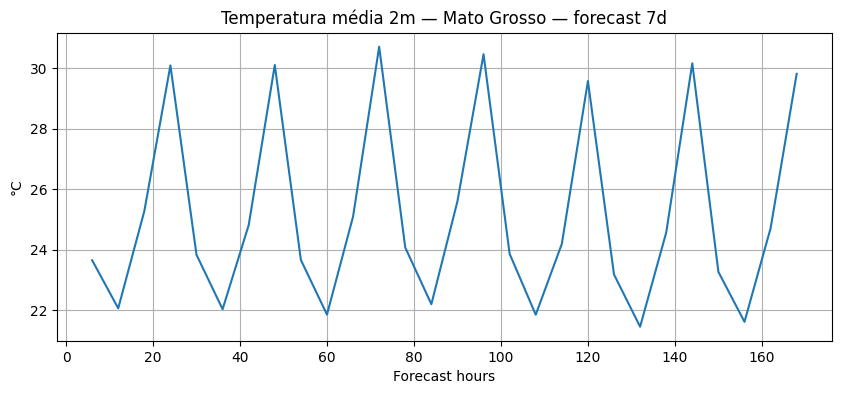

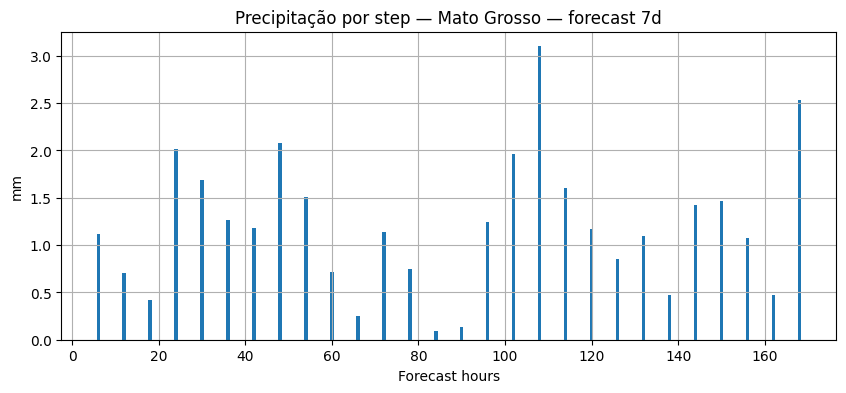

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(timeseries_df["forecast_hours"], timeseries_df["temperature_2m_c"])
plt.title("Temperatura média 2m — Mato Grosso — forecast 7d")
plt.xlabel("Forecast hours")
plt.ylabel("°C")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(timeseries_df["forecast_hours"], timeseries_df["precip_step_mm"])
plt.title("Precipitação por step — Mato Grosso — forecast 7d")
plt.xlabel("Forecast hours")
plt.ylabel("mm")
plt.grid(True)
plt.show()